In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
import joblib
from scipy.stats import randint, uniform

print("All libraries imported successfully")

All libraries imported successfully


In [4]:
df = pd.read_csv('Customer-Churn.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Dataset Info:")
df.info()
print("\nDescriptive Statistics:")
df.describe().T

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str  

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [6]:
# Fix TotalCharges (blank spaces -> NaN -> numeric)
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values before fill:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("\nMissing values after fill:", df.isnull().sum().sum(), "remaining nulls")

# Drop rows where tenure == 0 (invalid customers)
zero_tenure = df[df["tenure"] == 0]
print(f"\nRows with tenure == 0: {len(zero_tenure)}")
df = df[df["tenure"] > 0].reset_index(drop=True)

# Drop useless column
df.drop("customerID", axis=1, inplace=True)

# Encode target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(f"\nClean dataset shape: {df.shape}")
print("\nChurn distribution:")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

Missing values before fill:
TotalCharges    11
dtype: int64

Missing values after fill: 0 remaining nulls

Rows with tenure == 0: 11

Clean dataset shape: (7032, 20)

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    73.42%
1    26.58%
Name: proportion, dtype: str


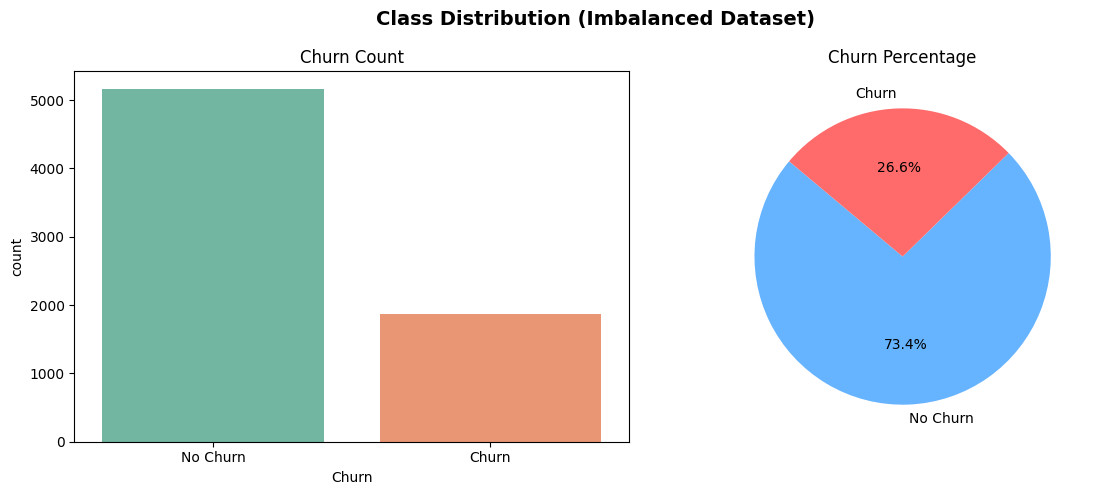


  Dataset is IMBALANCED — SMOTE will be applied before training


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="Churn", data=df, palette="Set2", ax=axes[0])
axes[0].set_title("Churn Count")
axes[0].set_xticklabels(["No Churn", "Churn"])

churn_counts = df["Churn"].value_counts()
axes[1].pie(churn_counts, labels=["No Churn", "Churn"],
            autopct="%1.1f%%", colors=["#66b3ff", "#ff6b6b"], startangle=140)
axes[1].set_title("Churn Percentage")

plt.suptitle("Class Distribution (Imbalanced Dataset)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n  Dataset is IMBALANCED — SMOTE will be applied before training")

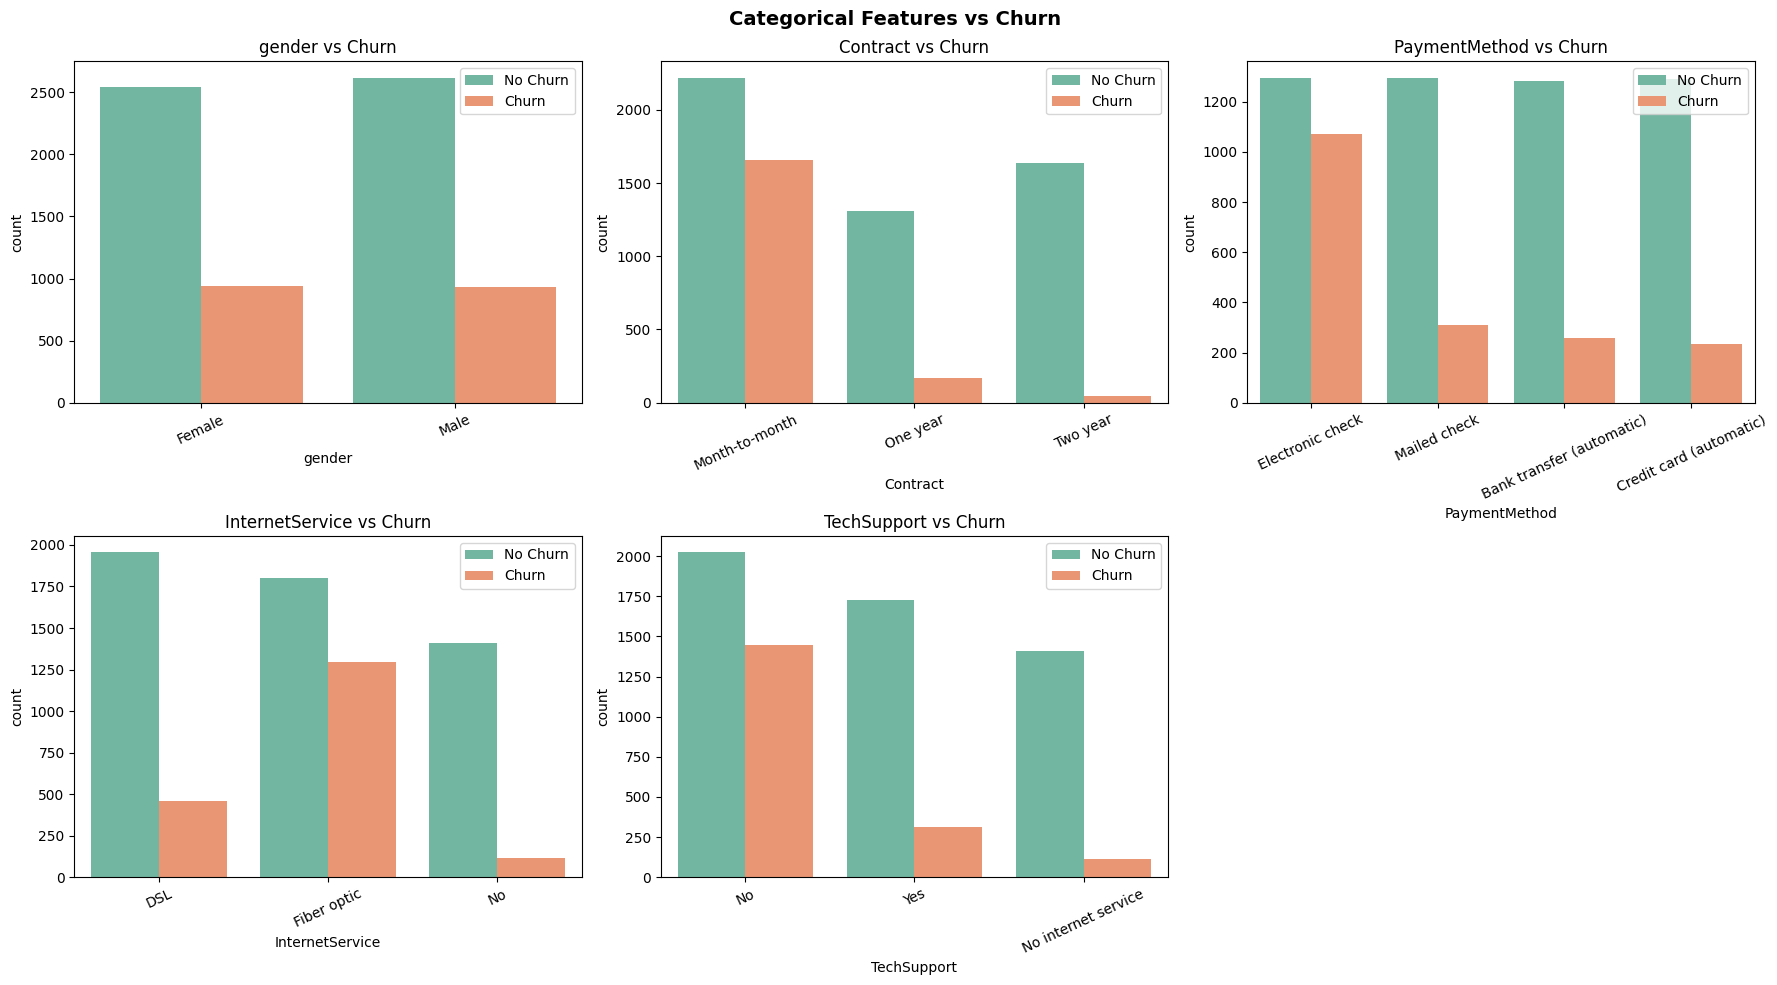

In [8]:
cat_cols = ["gender", "Contract", "PaymentMethod", "InternetService", "TechSupport"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue="Churn", data=df, palette="Set2", ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].legend(["No Churn", "Churn"])

axes[-1].set_visible(False)
plt.suptitle("Categorical Features vs Churn", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

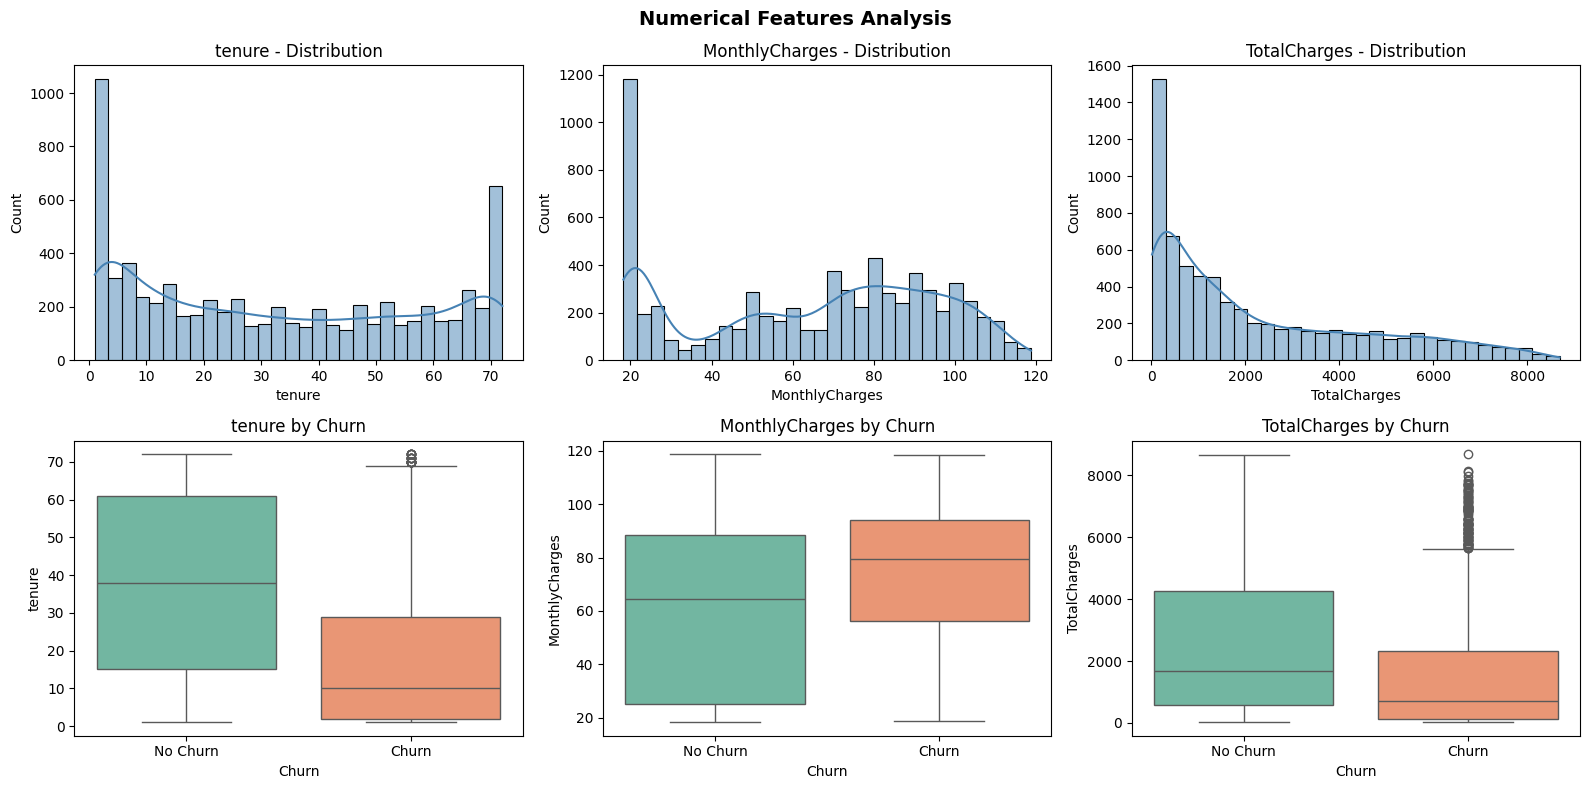

In [9]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[0][i], color="steelblue")
    axes[0][i].set_title(f"{col} - Distribution")
    sns.boxplot(x="Churn", y=col, data=df, palette="Set2", ax=axes[1][i])
    axes[1][i].set_title(f"{col} by Churn")
    axes[1][i].set_xticklabels(["No Churn", "Churn"])

plt.suptitle("Numerical Features Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

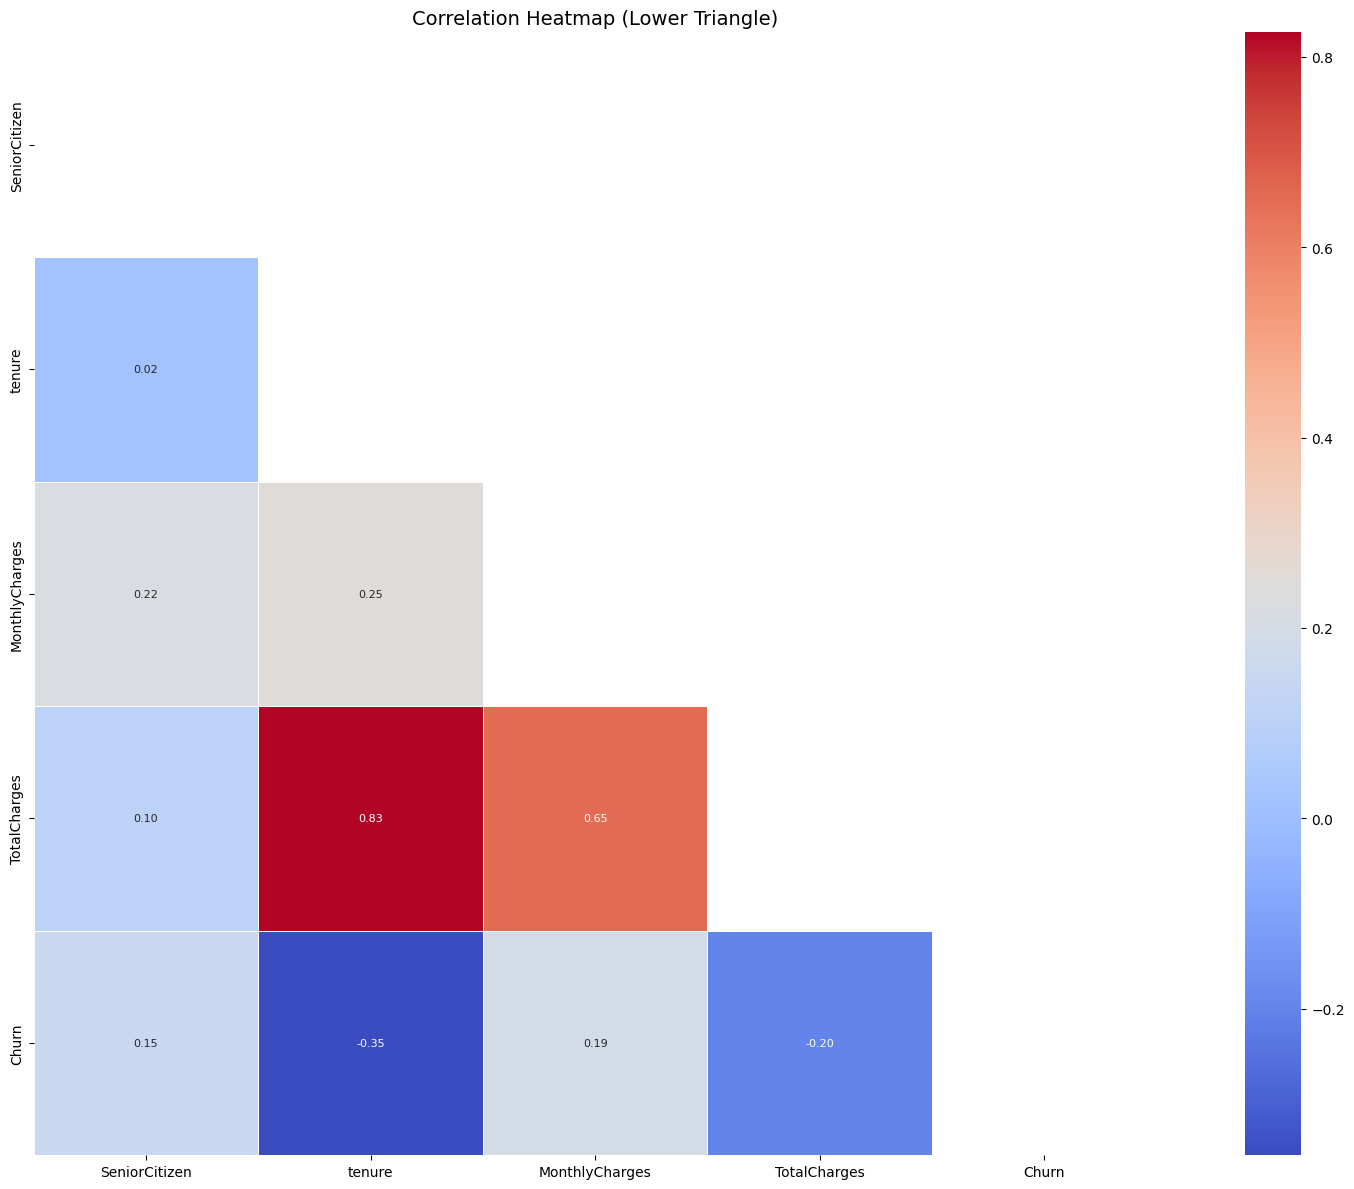


Top features correlated with Churn:
MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn, dtype: float64


In [10]:
df_encoded = df.copy()
encoder = LabelEncoder()
for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        df_encoded[col] = encoder.fit_transform(df_encoded[col])

plt.figure(figsize=(18, 12))
corr_matrix = df_encoded.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, square=True, linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Heatmap (Lower Triangle)", fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop features correlated with Churn:")
print(corr_matrix["Churn"].sort_values(ascending=False).drop("Churn"))

In [11]:
# Prepare features and target
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]
print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Features shape: (7032, 19)
Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [12]:
print(X.dtypes)
print("\nObject columns:", X.select_dtypes("object").columns.tolist())
print("Sample rows:")
X.head(3)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

Object columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Sample rows:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15


In [13]:
# Force encode any remaining string columns
encoder = LabelEncoder()
for col in X.columns:
    if X[col].dtype == "object" or X[col].dtype.name == "str":
        X[col] = encoder.fit_transform(X[col].astype(str))

print("Object columns remaining:", X.select_dtypes("object").columns.tolist())
print("All numeric?", (X.dtypes == "object").sum() == 0)

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE on training set only
print("\nBefore SMOTE:", y_train.value_counts().to_dict())
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)
print("After  SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

Object columns remaining: []
All numeric? True

Train: 5625 | Test: 1407

Before SMOTE: {0: 4130, 1: 1495}
After  SMOTE: {0: 4130, 1: 4130}


In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":                 SVC(probability=True, class_weight='balanced', random_state=42),
    "Naive Bayes":         GaussianNB(),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "AdaBoost":            AdaBoostClassifier(random_state=42),
    "Extra Trees":         ExtraTreesClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
}
print(f"{len(models)} models defined")

10 models defined



  BASELINE MODEL: Logistic Regression
  Accuracy : 0.7363
  Precision: 0.5025
  Recall   : 0.7914
  F1 Score : 0.6147
  ROC-AUC  : 0.8334
  PR-AUC   : 0.6221
  CV F1    : 0.7935 +/- 0.0024


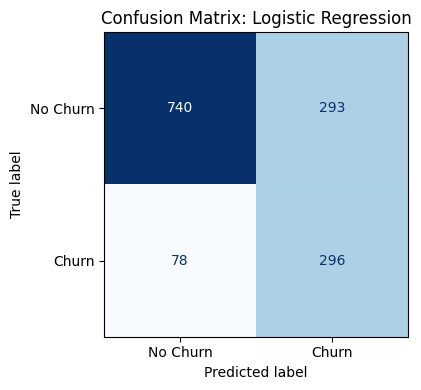


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1033
       Churn       0.50      0.79      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407


  BASELINE MODEL: KNN
  Accuracy : 0.7008
  Precision: 0.4609
  Recall   : 0.7406
  F1 Score : 0.5682
  ROC-AUC  : 0.7679
  PR-AUC   : 0.4736
  CV F1    : 0.8061 +/- 0.0055


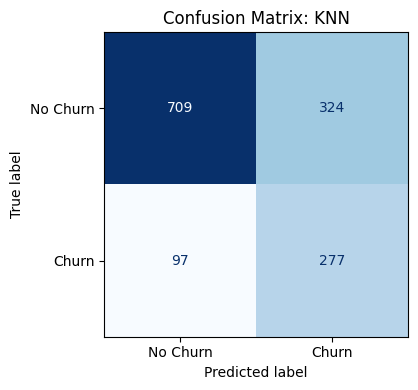


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.69      0.77      1033
       Churn       0.46      0.74      0.57       374

    accuracy                           0.70      1407
   macro avg       0.67      0.71      0.67      1407
weighted avg       0.77      0.70      0.72      1407


  BASELINE MODEL: Decision Tree
  Accuracy : 0.7171
  Precision: 0.4736
  Recall   : 0.5749
  F1 Score : 0.5193
  ROC-AUC  : 0.6718
  PR-AUC   : 0.3852
  CV F1    : 0.7932 +/- 0.0047


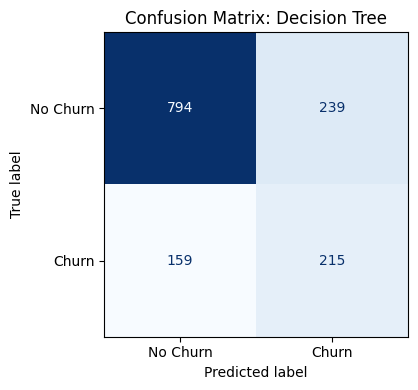


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.77      0.80      1033
       Churn       0.47      0.57      0.52       374

    accuracy                           0.72      1407
   macro avg       0.65      0.67      0.66      1407
weighted avg       0.74      0.72      0.73      1407


  BASELINE MODEL: Random Forest
  Accuracy : 0.7726
  Precision: 0.5699
  Recall   : 0.5882
  F1 Score : 0.5789
  ROC-AUC  : 0.8113
  PR-AUC   : 0.5825
  CV F1    : 0.8579 +/- 0.0046


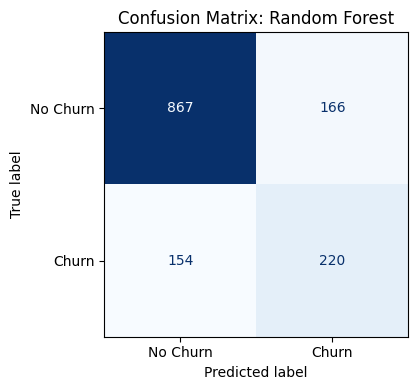


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.84      1033
       Churn       0.57      0.59      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407


  BASELINE MODEL: SVM
  Accuracy : 0.7470
  Precision: 0.5178
  Recall   : 0.7005
  F1 Score : 0.5955
  ROC-AUC  : 0.8068
  PR-AUC   : 0.5970
  CV F1    : 0.8156 +/- 0.0024


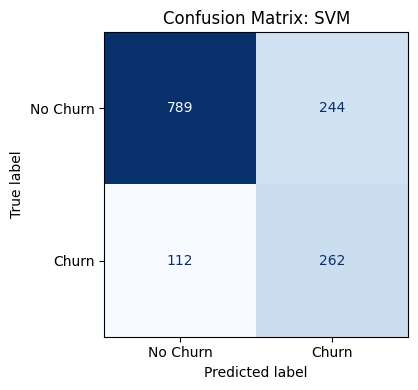


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.76      0.82      1033
       Churn       0.52      0.70      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407


  BASELINE MODEL: Naive Bayes
  Accuracy : 0.7235
  Precision: 0.4872
  Recall   : 0.7647
  F1 Score : 0.5952
  ROC-AUC  : 0.8103
  PR-AUC   : 0.5776
  CV F1    : 0.7821 +/- 0.0028


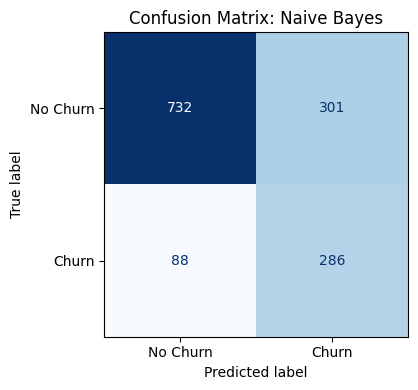


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.71      0.79      1033
       Churn       0.49      0.76      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.78      0.72      0.74      1407


  BASELINE MODEL: Gradient Boosting
  Accuracy : 0.7733
  Precision: 0.5586
  Recall   : 0.7005
  F1 Score : 0.6216
  ROC-AUC  : 0.8342
  PR-AUC   : 0.6375
  CV F1    : 0.8454 +/- 0.0026


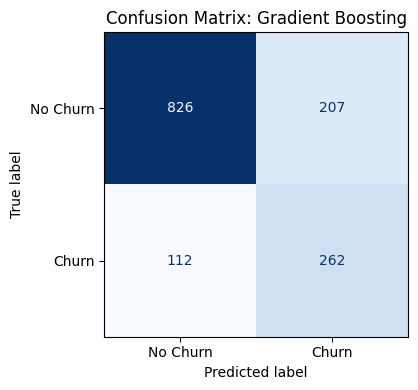


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1033
       Churn       0.56      0.70      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407


  BASELINE MODEL: AdaBoost
  Accuracy : 0.7356
  Precision: 0.5018
  Recall   : 0.7620
  F1 Score : 0.6051
  ROC-AUC  : 0.8309
  PR-AUC   : 0.6326
  CV F1    : 0.8136 +/- 0.0025


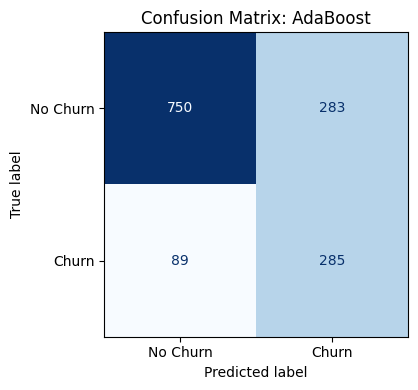


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.73      0.80      1033
       Churn       0.50      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.74      0.75      1407


  BASELINE MODEL: Extra Trees
  Accuracy : 0.7569
  Precision: 0.5435
  Recall   : 0.5348
  F1 Score : 0.5391
  ROC-AUC  : 0.7856
  PR-AUC   : 0.5418
  CV F1    : 0.8620 +/- 0.0028


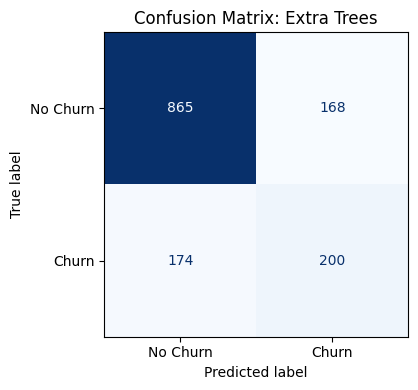


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.84      0.83      1033
       Churn       0.54      0.53      0.54       374

    accuracy                           0.76      1407
   macro avg       0.69      0.69      0.69      1407
weighted avg       0.76      0.76      0.76      1407


  BASELINE MODEL: XGBoost
  Accuracy : 0.7655
  Precision: 0.5558
  Recall   : 0.5856
  F1 Score : 0.5703
  ROC-AUC  : 0.8092
  PR-AUC   : 0.5993
  CV F1    : 0.8517 +/- 0.0062


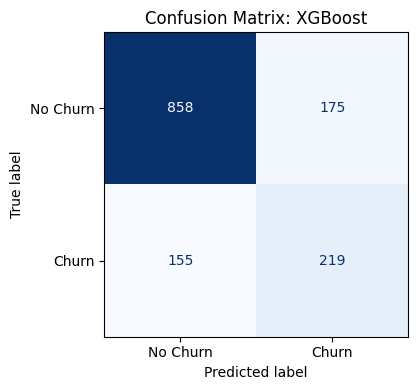


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.83      0.84      1033
       Churn       0.56      0.59      0.57       374

    accuracy                           0.77      1407
   macro avg       0.70      0.71      0.70      1407
weighted avg       0.77      0.77      0.77      1407



In [15]:
results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"  BASELINE MODEL: {name}")
    print(f"{'='*50}")

    model.fit(X_train_sm, y_train_sm)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    roc_auc   = roc_auc_score(y_test, y_prob)
    pr_auc    = average_precision_score(y_test, y_prob)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1 = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='f1')

    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  ROC-AUC  : {roc_auc:.4f}")
    print(f"  PR-AUC   : {pr_auc:.4f}")
    print(f"  CV F1    : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")

    results.append({
        "Model":      name,
        "Accuracy":   round(accuracy, 4),
        "Precision":  round(precision, 4),
        "Recall":     round(recall, 4),
        "F1 Score":   round(f1, 4),
        "ROC-AUC":    round(roc_auc, 4),
        "PR-AUC":     round(pr_auc, 4),
        "CV F1 Mean": round(cv_f1.mean(), 4),
        "CV F1 Std":  round(cv_f1.std(), 4),
    })

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

In [16]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

print("="*70)
print("   FINAL MODEL COMPARISON TABLE  (sorted by ROC-AUC)")
print("="*70)
results_df

   FINAL MODEL COMPARISON TABLE  (sorted by ROC-AUC)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,CV F1 Mean,CV F1 Std
0,Gradient Boosting,0.7733,0.5586,0.7005,0.6216,0.8342,0.6375,0.8454,0.0026
1,Logistic Regression,0.7363,0.5025,0.7914,0.6147,0.8334,0.6221,0.7935,0.0024
2,AdaBoost,0.7356,0.5018,0.7620,0.6051,0.8309,0.6326,0.8136,0.0025
3,Random Forest,0.7726,0.5699,0.5882,0.5789,0.8113,0.5825,0.8579,0.0046
4,Naive Bayes,0.7235,0.4872,0.7647,0.5952,0.8103,0.5776,0.7821,0.0028
5,XGBoost,0.7655,0.5558,0.5856,0.5703,0.8092,0.5993,0.8517,0.0062
6,SVM,0.7470,0.5178,0.7005,0.5955,0.8068,0.5970,0.8156,0.0024
7,Extra Trees,0.7569,0.5435,0.5348,0.5391,0.7856,0.5418,0.8620,0.0028
8,KNN,0.7008,0.4609,0.7406,0.5682,0.7679,0.4736,0.8061,0.0055
9,Decision Tree,0.7171,0.4736,0.5749,0.5193,0.6718,0.3852,0.7932,0.0047


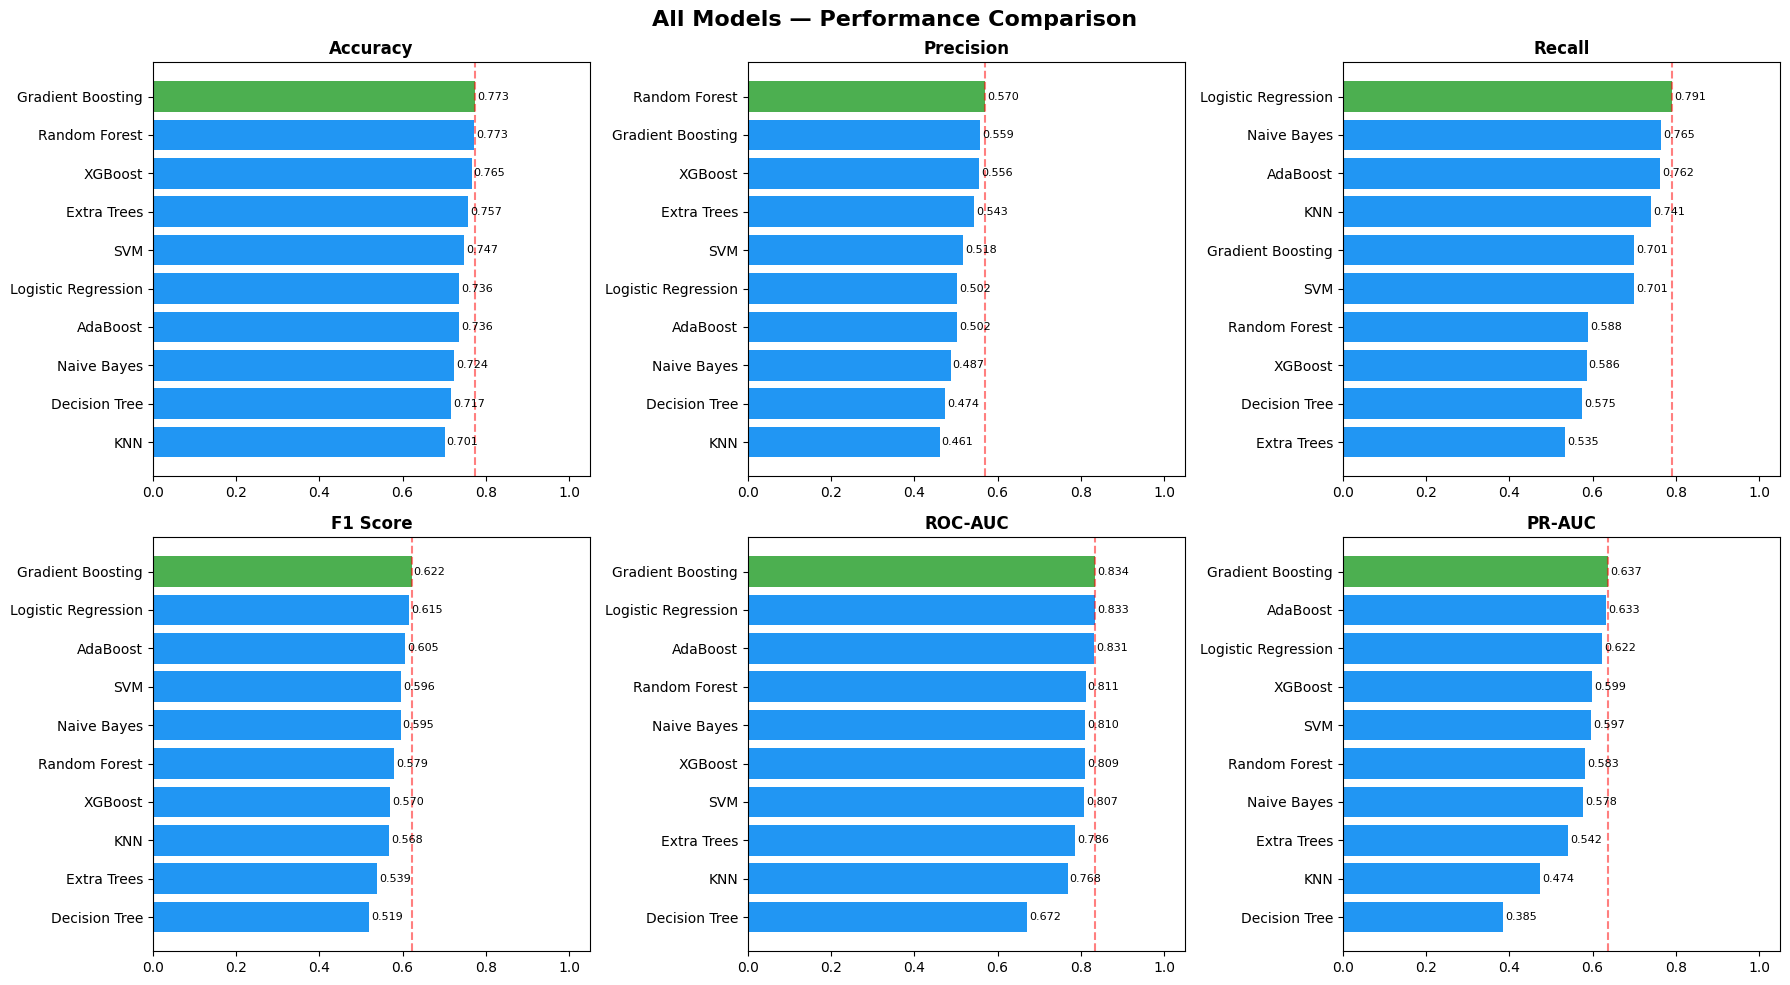

In [17]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sorted_df = results_df.sort_values(by=metric, ascending=True)
    best_val = sorted_df[metric].max()
    colors = ["#4CAF50" if x == best_val else "#2196F3" for x in sorted_df[metric]]
    axes[i].barh(sorted_df["Model"], sorted_df[metric], color=colors)
    axes[i].set_title(f"{metric}", fontweight='bold')
    axes[i].set_xlim(0, 1.05)
    axes[i].axvline(best_val, color='red', linestyle='--', alpha=0.5, label='Best')
    for j, val in enumerate(sorted_df[metric]):
        axes[i].text(val + 0.005, j, f"{val:.3f}", va='center', fontsize=8)

plt.suptitle("All Models — Performance Comparison", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ─────────────────────────────────────────────────────────────
# STEP 1 — Define param grids for the top models
# ─────────────────────────────────────────────────────────────

param_grids = {
    "Logistic Regression": {
        "method": "grid",
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10, 100],
            "solver": ["lbfgs", "liblinear"],
            "penalty": ["l2"]
        }
    },
    "Random Forest": {
        "method": "random",
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": randint(100, 500),
            "max_depth": [None, 5, 10, 20, 30],
            "min_samples_split": randint(2, 20),
            "min_samples_leaf": randint(1, 10),
            "max_features": ["sqrt", "log2", None]
        }
    },
    "Gradient Boosting": {
        "method": "random",
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": randint(100, 400),
            "learning_rate": uniform(0.01, 0.3),
            "max_depth": [3, 4, 5, 6, 7],
            "subsample": uniform(0.6, 0.4),
            "min_samples_split": randint(2, 20)
        }
    },
    "XGBoost": {
        "method": "random",
        "model": XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
        "params": {
            "n_estimators": randint(100, 400),
            "learning_rate": uniform(0.01, 0.3),
            "max_depth": randint(3, 10),
            "subsample": uniform(0.6, 0.4),
            "colsample_bytree": uniform(0.6, 0.4),
            "gamma": uniform(0, 0.5),
            "reg_alpha": uniform(0, 1),
            "reg_lambda": uniform(0.5, 2)
        }
    },
    "Extra Trees": {
        "method": "random",
        "model": ExtraTreesClassifier(random_state=42),
        "params": {
            "n_estimators": randint(100, 400),
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": randint(2, 20),
            "min_samples_leaf": randint(1, 10),
            "max_features": ["sqrt", "log2", None]
        }
    },
    "Decision Tree": {
        "method": "grid",
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [3, 5, 7, 10, None],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 4, 8],
            "criterion": ["gini", "entropy"]
        }
    },
    "KNN": {
        "method": "grid",
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9, 11, 15],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"]
        }
    },
    "AdaBoost": {
        "method": "random",
        "model": AdaBoostClassifier(random_state=42),
        "params": {
            "n_estimators": randint(50, 300),
            "learning_rate": uniform(0.01, 1.5)
        }
    },
}

print(f"Hyperparameter grids defined for {len(param_grids)} models")
print("\nMethod summary:")
for name, cfg in param_grids.items():
    print(f"  {name:25s} → {cfg['method'].upper()}SearchCV")

Hyperparameter grids defined for 8 models

Method summary:
  Logistic Regression       → GRIDSearchCV
  Random Forest             → RANDOMSearchCV
  Gradient Boosting         → RANDOMSearchCV
  XGBoost                   → RANDOMSearchCV
  Extra Trees               → RANDOMSearchCV
  Decision Tree             → GRIDSearchCV
  KNN                       → GRIDSearchCV
  AdaBoost                  → RANDOMSearchCV



  TUNING: Logistic Regression  [GRIDSearchCV]
  Best CV ROC-AUC : 0.8635
  Best Params     : {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}

  Test Results:
    Accuracy : 0.7363
    Precision: 0.5025
    Recall   : 0.7914
    F1 Score : 0.6147
    ROC-AUC  : 0.8336
    PR-AUC   : 0.6226


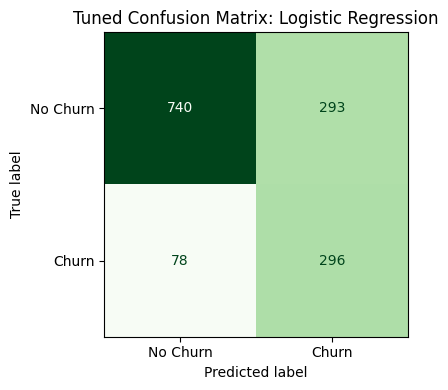


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1033
       Churn       0.50      0.79      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407


  TUNING: Random Forest  [RANDOMSearchCV]
  Best CV ROC-AUC : 0.9240
  Best Params     : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 403}

  Test Results:
    Accuracy : 0.7747
    Precision: 0.5674
    Recall   : 0.6417
    F1 Score : 0.6023
    ROC-AUC  : 0.8236
    PR-AUC   : 0.6123


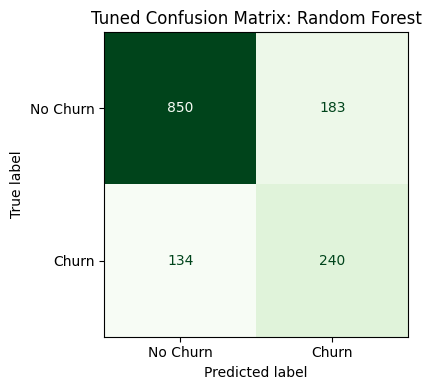


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1033
       Churn       0.57      0.64      0.60       374

    accuracy                           0.77      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.79      0.77      0.78      1407


  TUNING: Gradient Boosting  [RANDOMSearchCV]
  Best CV ROC-AUC : 0.9359
  Best Params     : {'learning_rate': np.float64(0.0969254358741304), 'max_depth': 6, 'min_samples_split': 3, 'n_estimators': 269, 'subsample': np.float64(0.9232481518257668)}

  Test Results:
    Accuracy : 0.7669
    Precision: 0.5569
    Recall   : 0.6016
    F1 Score : 0.5784
    ROC-AUC  : 0.8165
    PR-AUC   : 0.6078


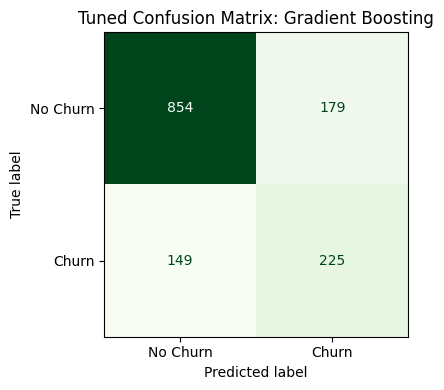


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.83      0.84      1033
       Churn       0.56      0.60      0.58       374

    accuracy                           0.77      1407
   macro avg       0.70      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407


  TUNING: XGBoost  [RANDOMSearchCV]
  Best CV ROC-AUC : 0.9360
  Best Params     : {'colsample_bytree': np.float64(0.8605939087431151), 'gamma': np.float64(0.10334217993837269), 'learning_rate': np.float64(0.09218833819634012), 'max_depth': 6, 'n_estimators': 194, 'reg_alpha': np.float64(0.37725908322797586), 'reg_lambda': np.float64(0.5779262646204673), 'subsample': np.float64(0.8473015537351571)}

  Test Results:
    Accuracy : 0.7704
    Precision: 0.5636
    Recall   : 0.6043
    F1 Score : 0.5832
    ROC-AUC  : 0.8218
    PR-AUC   : 0.6281


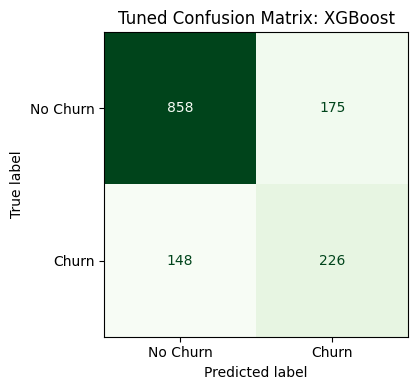


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.83      0.84      1033
       Churn       0.56      0.60      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.77      1407


  TUNING: Extra Trees  [RANDOMSearchCV]
  Best CV ROC-AUC : 0.9333
  Best Params     : {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 229}

  Test Results:
    Accuracy : 0.7605
    Precision: 0.5499
    Recall   : 0.5455
    F1 Score : 0.5477
    ROC-AUC  : 0.7998
    PR-AUC   : 0.5555


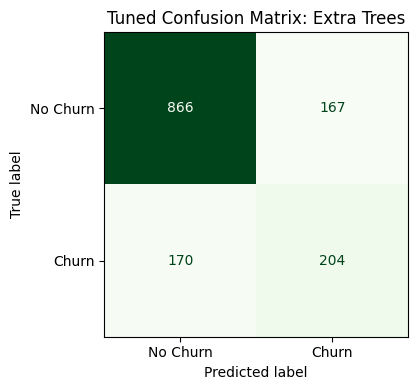


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.84      0.84      1033
       Churn       0.55      0.55      0.55       374

    accuracy                           0.76      1407
   macro avg       0.69      0.69      0.69      1407
weighted avg       0.76      0.76      0.76      1407


  TUNING: Decision Tree  [GRIDSearchCV]
  Best CV ROC-AUC : 0.8788
  Best Params     : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 20}

  Test Results:
    Accuracy : 0.7477
    Precision: 0.5191
    Recall   : 0.6898
    F1 Score : 0.5924
    ROC-AUC  : 0.7962
    PR-AUC   : 0.5586


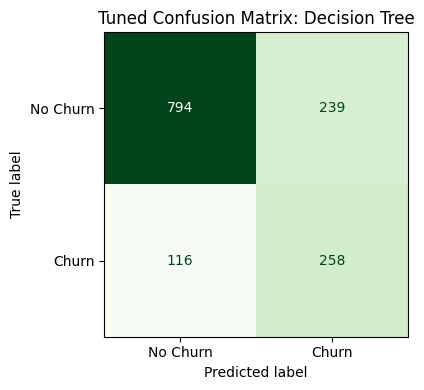


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.77      0.82      1033
       Churn       0.52      0.69      0.59       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.70      1407
weighted avg       0.78      0.75      0.76      1407


  TUNING: KNN  [GRIDSearchCV]
  Best CV ROC-AUC : 0.8977
  Best Params     : {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}

  Test Results:
    Accuracy : 0.7257
    Precision: 0.4887
    Recall   : 0.6925
    F1 Score : 0.5730
    ROC-AUC  : 0.7764
    PR-AUC   : 0.5233


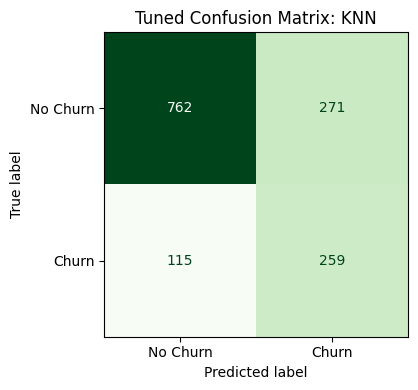


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.74      0.80      1033
       Churn       0.49      0.69      0.57       374

    accuracy                           0.73      1407
   macro avg       0.68      0.72      0.69      1407
weighted avg       0.77      0.73      0.74      1407


  TUNING: AdaBoost  [RANDOMSearchCV]
  Best CV ROC-AUC : 0.9268
  Best Params     : {'learning_rate': np.float64(1.4848463287101823), 'n_estimators': 298}

  Test Results:
    Accuracy : 0.7747
    Precision: 0.5605
    Recall   : 0.7059
    F1 Score : 0.6249
    ROC-AUC  : 0.8341
    PR-AUC   : 0.6409


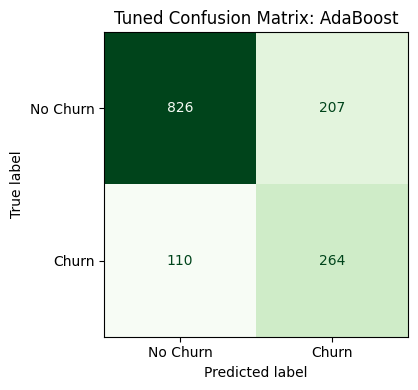


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1033
       Churn       0.56      0.71      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407



In [19]:
# STEP 2 — Run Hyperparameter Search

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_results = []
tuned_models  = {}

for name, cfg in param_grids.items():
    print(f"\n{'='*55}")
    print(f"  TUNING: {name}  [{cfg['method'].upper()}SearchCV]")
    print(f"{'='*55}")

    if cfg["method"] == "grid":
        searcher = GridSearchCV(
            estimator=cfg["model"],
            param_grid=cfg["params"],
            cv=cv_strategy,
            scoring="roc_auc",
            n_jobs=-1,
            verbose=0
        )
    else:  # random
        searcher = RandomizedSearchCV(
            estimator=cfg["model"],
            param_distributions=cfg["params"],
            n_iter=50,          # 50 random combos — fast but thorough
            cv=cv_strategy,
            scoring="roc_auc",
            random_state=42,
            n_jobs=-1,
            verbose=0
        )

    searcher.fit(X_train_sm, y_train_sm)

    best_model  = searcher.best_estimator_
    best_params = searcher.best_params_
    best_cv_roc = searcher.best_score_

    print(f"  Best CV ROC-AUC : {best_cv_roc:.4f}")
    print(f"  Best Params     : {best_params}")

    # Evaluate on hold-out test set
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    roc_auc   = roc_auc_score(y_test, y_prob)
    pr_auc    = average_precision_score(y_test, y_prob)

    print(f"\n  Test Results:")
    print(f"    Accuracy : {accuracy:.4f}")
    print(f"    Precision: {precision:.4f}")
    print(f"    Recall   : {recall:.4f}")
    print(f"    F1 Score : {f1:.4f}")
    print(f"    ROC-AUC  : {roc_auc:.4f}")
    print(f"    PR-AUC   : {pr_auc:.4f}")

    tuned_models[name] = best_model
    tuned_results.append({
        "Model":           name,
        "Accuracy":        round(accuracy, 4),
        "Precision":       round(precision, 4),
        "Recall":          round(recall, 4),
        "F1 Score":        round(f1, 4),
        "ROC-AUC":         round(roc_auc, 4),
        "PR-AUC":          round(pr_auc, 4),
        "CV ROC-AUC":      round(best_cv_roc, 4),
        "Best Params":     str(best_params),
    })

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, cmap='Greens', colorbar=False)
    ax.set_title(f"Tuned Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

In [20]:
# STEP 3 — Tuned Models Comparison Table

tuned_df = pd.DataFrame(tuned_results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

print("="*70)
print("   TUNED MODEL COMPARISON  (sorted by ROC-AUC)")
print("="*70)
display_cols = ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC", "CV ROC-AUC"]
print(tuned_df[display_cols].to_string(index=False))

   TUNED MODEL COMPARISON  (sorted by ROC-AUC)
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC  CV ROC-AUC
           AdaBoost    0.7747     0.5605  0.7059    0.6249   0.8341  0.6409      0.9268
Logistic Regression    0.7363     0.5025  0.7914    0.6147   0.8336  0.6226      0.8635
      Random Forest    0.7747     0.5674  0.6417    0.6023   0.8236  0.6123      0.9240
            XGBoost    0.7704     0.5636  0.6043    0.5832   0.8218  0.6281      0.9360
  Gradient Boosting    0.7669     0.5569  0.6016    0.5784   0.8165  0.6078      0.9359
        Extra Trees    0.7605     0.5499  0.5455    0.5477   0.7998  0.5555      0.9333
      Decision Tree    0.7477     0.5191  0.6898    0.5924   0.7962  0.5586      0.8788
                KNN    0.7257     0.4887  0.6925    0.5730   0.7764  0.5233      0.8977


   BEFORE vs AFTER TUNING
              Model  Baseline ROC-AUC  Baseline F1  Tuned ROC-AUC  Tuned F1  ΔROC-AUC     ΔF1
           AdaBoost            0.8309       0.6051         0.8341    0.6249    0.0032  0.0198
Logistic Regression            0.8334       0.6147         0.8336    0.6147    0.0002  0.0000
      Random Forest            0.8113       0.5789         0.8236    0.6023    0.0123  0.0234
            XGBoost            0.8092       0.5703         0.8218    0.5832    0.0126  0.0129
  Gradient Boosting            0.8342       0.6216         0.8165    0.5784   -0.0177 -0.0432
        Extra Trees            0.7856       0.5391         0.7998    0.5477    0.0142  0.0086
      Decision Tree            0.6718       0.5193         0.7962    0.5924    0.1244  0.0731
                KNN            0.7679       0.5682         0.7764    0.5730    0.0085  0.0048


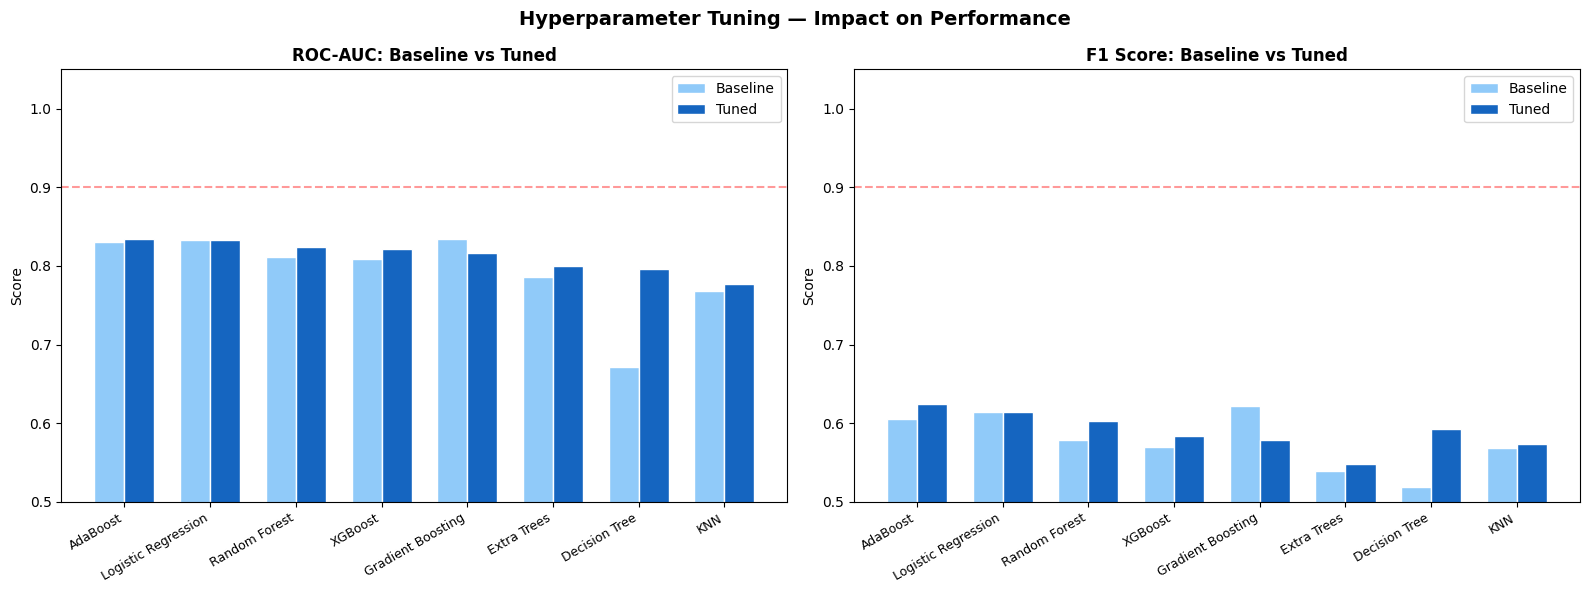

In [21]:
# STEP 4 — Before vs After Tuning: Visual Comparison

baseline_df = pd.DataFrame(results).rename(columns={"ROC-AUC": "Baseline ROC-AUC", "F1 Score": "Baseline F1"})
tuned_cmp   = tuned_df[["Model", "ROC-AUC", "F1 Score"]].rename(
    columns={"ROC-AUC": "Tuned ROC-AUC", "F1 Score": "Tuned F1"})

compare_df = baseline_df[["Model", "Baseline ROC-AUC", "Baseline F1"]].merge(tuned_cmp, on="Model", how="inner")
compare_df["ΔROC-AUC"] = (compare_df["Tuned ROC-AUC"] - compare_df["Baseline ROC-AUC"]).round(4)
compare_df["ΔF1"]      = (compare_df["Tuned F1"]      - compare_df["Baseline F1"]).round(4)
compare_df = compare_df.sort_values("Tuned ROC-AUC", ascending=False).reset_index(drop=True)

print("="*80)
print("   BEFORE vs AFTER TUNING")
print("="*80)
print(compare_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(compare_df))
w = 0.35

for ax, base_col, tuned_col, title in [
    (axes[0], "Baseline ROC-AUC", "Tuned ROC-AUC", "ROC-AUC: Baseline vs Tuned"),
    (axes[1], "Baseline F1",      "Tuned F1",      "F1 Score: Baseline vs Tuned"),
]:
    ax.bar(x - w/2, compare_df[base_col],  w, label="Baseline", color="#90CAF9", edgecolor="white")
    ax.bar(x + w/2, compare_df[tuned_col], w, label="Tuned",    color="#1565C0", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(compare_df["Model"], rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0.5, 1.05)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.set_ylabel("Score")
    ax.axhline(0.9, color="red", linestyle="--", alpha=0.4, label="0.90 line")

plt.suptitle("Hyperparameter Tuning — Impact on Performance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

BEST TUNED MODEL  : AdaBoost
  ROC-AUC         : 0.8341
  F1 Score        : 0.6249
  Recall          : 0.7059
  CV ROC-AUC      : 0.9268
  Best Params     : {'learning_rate': np.float64(1.4848463287101823), 'n_estimators': 298}


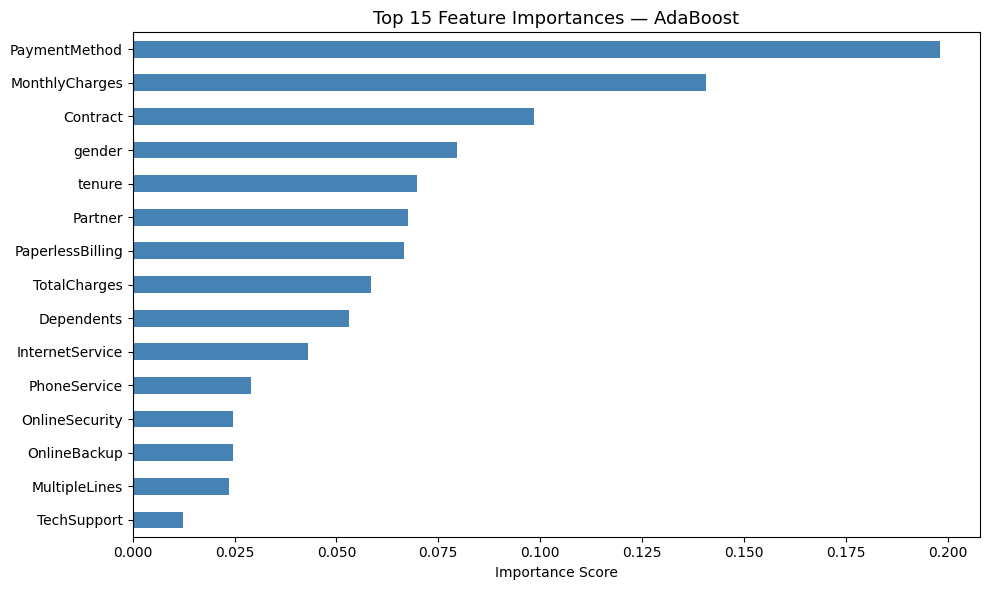


Tuned model saved as 'best_churn_model_tuned.pkl'
Scaler saved as 'scaler.pkl'

Project Complete! ✓


In [22]:
# STEP 5 — Best Tuned Model: Deep Dive & Save

best_tuned_row   = tuned_df.iloc[0]
best_tuned_name  = best_tuned_row["Model"]
best_tuned_model = tuned_models[best_tuned_name]

print(f"BEST TUNED MODEL  : {best_tuned_name}")
print(f"  ROC-AUC         : {best_tuned_row['ROC-AUC']}")
print(f"  F1 Score        : {best_tuned_row['F1 Score']}")
print(f"  Recall          : {best_tuned_row['Recall']}")
print(f"  CV ROC-AUC      : {best_tuned_row['CV ROC-AUC']}")
print(f"  Best Params     : {best_tuned_row['Best Params']}")

# Feature Importance / Coefficients
if hasattr(best_tuned_model, "feature_importances_"):
    feat_imp = pd.Series(best_tuned_model.feature_importances_,
                         index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='barh', color='steelblue')
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Feature Importances — {best_tuned_name}", fontsize=13)
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()
elif hasattr(best_tuned_model, "coef_"):
    feat_imp = pd.Series(np.abs(best_tuned_model.coef_[0]),
                         index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='barh', color='coral')
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Feature Coefficients — {best_tuned_name}", fontsize=13)
    plt.xlabel("|Coefficient|")
    plt.tight_layout()
    plt.show()

# Save tuned model and scaler
joblib.dump(best_tuned_model, "best_churn_model_tuned.pkl")
joblib.dump(scaler, "scaler.pkl")
print("\nTuned model saved as 'best_churn_model_tuned.pkl'")
print("Scaler saved as 'scaler.pkl'")
print("\nProject Complete! ✓")

BEST MODEL: Gradient Boosting
  ROC-AUC  : 0.8342
  F1 Score : 0.6216
  Recall   : 0.7005
  CV F1    : 0.8454 +/- 0.0026


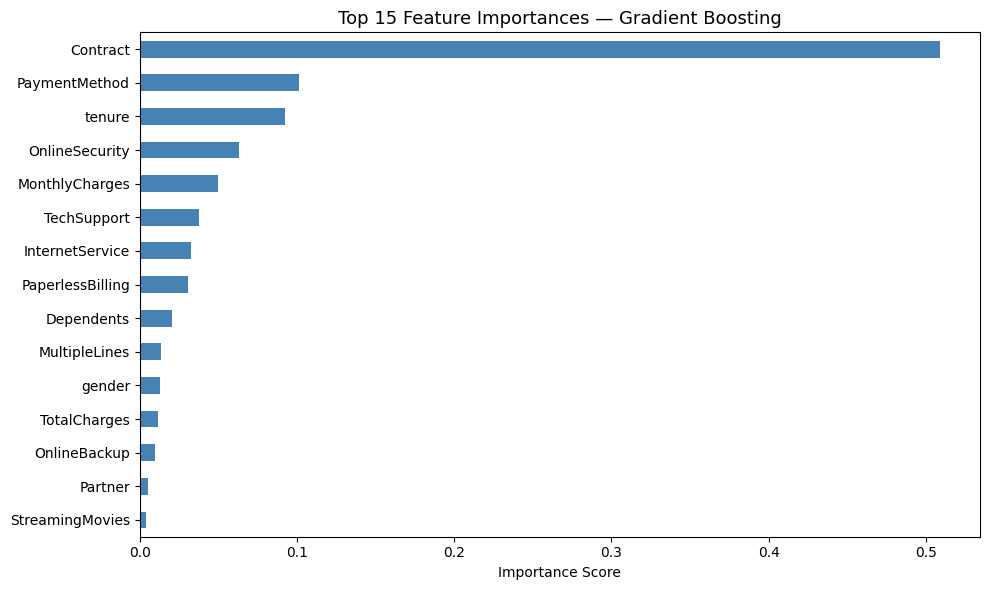


Model saved as 'best_churn_model.pkl'
Scaler saved as 'scaler.pkl'

Project Complete!


In [23]:
best_row  = results_df.iloc[0]
best_name = best_row["Model"]
best_model = models[best_name]

print(f"BEST MODEL: {best_name}")
print(f"  ROC-AUC  : {best_row['ROC-AUC']}")
print(f"  F1 Score : {best_row['F1 Score']}")
print(f"  Recall   : {best_row['Recall']}")
print(f"  CV F1    : {best_row['CV F1 Mean']} +/- {best_row['CV F1 Std']}")

# Feature Importance
if hasattr(best_model, "feature_importances_"):
    feat_imp = pd.Series(best_model.feature_importances_,
                         index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='barh', color='steelblue')
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Feature Importances — {best_name}", fontsize=13)
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, "coef_"):
    feat_imp = pd.Series(np.abs(best_model.coef_[0]),
                         index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='barh', color='coral')
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Feature Coefficients — {best_name}", fontsize=13)
    plt.xlabel("|Coefficient|")
    plt.tight_layout()
    plt.show()

# Save best model and scaler
joblib.dump(best_model, "best_churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("\nModel saved as 'best_churn_model.pkl'")
print("Scaler saved as 'scaler.pkl'")
print("\nProject Complete!")